# Точный фильтр против ЦПТ-аппроксимации на трёх каналах наблюдений

Одна и та же скрытая траектория $(\theta_t, Y_t)$ пропущена через три канала
наблюдений -- Парето, экспоненциальный, равномерный -- и для каждого канала
сравниваются два фильтра:

- **точный** -- работает по правдоподобию исходного распределения на шаге
  $h_t=1$;
- **ЦПТ (CLT)** -- работает по гауссовской аппроксимации среднего блока из
  `ratio` подряд идущих наблюдений (шаг $h_t = \mathrm{ratio}$), матчинг
  первых двух моментов.

Порождающая модель одного наблюдения (шаг $h_t=1$):

$$X = Y_1 + Y_2\,\varepsilon,\qquad \mathbb E[\varepsilon]=1,\quad
\mathrm{Var}[\varepsilon] = \tfrac1{12}$$

(конкретный вид $\varepsilon$ свой для каждого канала -- см. `pareto_obs.py`,
`exponential_obs.py`, `uniform_obs.py`), откуда

$$\mathbb E[X\mid Y] = Y_1+Y_2,\qquad \mathrm{Var}[X\mid Y] = \frac{Y_2^2}{12}.$$

Для среднего блока $\bar X_m = \frac1{\mathrm{ratio}}\sum_{k=1}^{\mathrm{ratio}} X_{(m-1)\mathrm{ratio}+k}$
по ЦПТ

$$\bar X_m \approx N\!\left(Y_1+Y_2,\ \frac{Y_2^2}{12\,\mathrm{ratio}}\right).$$

| канал | ratio | $h_t$ ЦПТ |
|---|---|---|
| pareto | 10 | 10 |
| exponential | 10 | 10 |
| uniform | 1 | 1 |

Ноутбук **ничего не пересчитывает** -- только загружает готовый
`saved_path_<EXP_ID>/comparison.npz`, посчитанный
`scripts/run_channel_clt_comparison.py` (см. план
`plans/20260908-channel-clt-comparison.md`).

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

EXP_ID = os.environ.get('CHANNEL_CLT_EXP_ID', 'channel_clt_comparison')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

ROOT = Path.cwd().resolve()
if not (ROOT / f'saved_path_{EXP_ID}' / 'comparison.npz').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / f'saved_path_{EXP_ID}'
assert (DATA_DIR / 'comparison.npz').exists(), 'Запускать из корня репозитория или из notebooks/'

with np.load(DATA_DIR / 'comparison.npz', allow_pickle=False) as archive:
    data = {name: archive[name] for name in archive.files}

# общая скрытая траектория -- одна на все каналы
theta, y, t = data['theta'], data['y'], data['t']
N = int(data['N'])
T = float(data['T'])
# состав и порядок каналов -- из архива, не хардкодим: прогон мог быть с --channels
channels = [str(c) for c in data['channels']]

print(f'эксперимент: {EXP_ID!r}')
print(f'каналы: {channels}, N={N} состояний, T={T/3600:.2f} ч (горизонт конфига)')
print(f'скачков theta в траектории: {len(t)}')

эксперимент: 'channel_clt_comparison_smoke'
каналы: ['pareto', 'exponential', 'uniform'], N=4 состояний, T=24.00 ч (горизонт конфига)
скачков theta в траектории: 21


In [2]:
def path_at(grid):
    # theta[k], y[k] действуют от предыдущего скачка до t[k] включительно
    idx = np.searchsorted(t, grid, side='left')
    return theta[idx], y[idx]


def trim(*arrays):
    # оценки фильтра могут быть короче сетки при досрочном останове --
    # везде режем по минимальной длине, не падаем
    n = min(a.shape[0] for a in arrays)
    return [a[:n] for a in arrays]


channel_data = {}
for c in channels:
    ratio = int(data[f'ratio_{c}'])
    ht_exact = float(data[f'ht_exact_{c}'])
    ht_clt = float(data[f'ht_clt_{c}'])
    n_exact = int(data[f'n_exact_{c}'])
    n_blocks = int(data[f'n_blocks_{c}'])
    obs = data[f'obs_{c}'][:, 0]
    obs_mean = data[f'obs_mean_{c}'][:, 0]
    # сетки наблюдений -- всегда полной длины (не зависят от останова фильтра)
    t_net_exact = data[f't_net_exact_{c}']
    t_net_clt = data[f't_net_clt_{c}']
    # оценки фильтра -- обрезаем парой со своей сеткой по min длине
    t_net_exact_est, th_exact, y_exact = trim(
        t_net_exact, data[f'theta_est_exact_{c}'], data[f'y_est_exact_{c}'])
    t_net_clt_est, th_clt, y_clt = trim(
        t_net_clt, data[f'theta_est_clt_{c}'], data[f'y_est_clt_{c}'])
    channel_data[c] = dict(
        ratio=ratio, ht_exact=ht_exact, ht_clt=ht_clt,
        n_exact=n_exact, n_blocks=n_blocks,
        obs=obs, obs_mean=obs_mean,
        t_net_exact=t_net_exact, t_net_clt=t_net_clt,
        t_net_exact_est=t_net_exact_est, th_exact=th_exact, y_exact=y_exact,
        t_net_clt_est=t_net_clt_est, th_clt=th_clt, y_clt=y_clt,
    )

print(f'{"канал":<14}{"ratio":>6}{"ht точн.":>10}{"ht ЦПТ":>8}'
      f'{"шагов точн.":>13}{"шагов ЦПТ":>11}{"горизонт, ч":>13}')
for c in channels:
    d = channel_data[c]
    horizon_h = d['n_exact'] * d['ht_exact'] / 3600
    print(f'{c:<14}{d["ratio"]:>6}{d["ht_exact"]:>10.0f}{d["ht_clt"]:>8.0f}'
          f'{d["n_exact"]:>13}{d["n_blocks"]:>11}{horizon_h:>13.3f}')
    if d['th_exact'].shape[0] < d['n_exact'] + 1:
        print(f'  внимание: точный фильтр канала {c} остановлен досрочно '
              f'({d["th_exact"].shape[0]} из {d["n_exact"] + 1} точек)')
    if d['th_clt'].shape[0] < d['n_blocks'] + 1:
        print(f'  внимание: ЦПТ-фильтр канала {c} остановлен досрочно '
              f'({d["th_clt"].shape[0]} из {d["n_blocks"] + 1} точек)')

канал          ratio  ht точн.  ht ЦПТ  шагов точн.  шагов ЦПТ  горизонт, ч
pareto            10         1      10          180         18        0.050
exponential       10         1      10          180         18        0.050
uniform            1         1       1          180        180        0.050


## 2. Общая скрытая траектория

Одна и та же реализация $(\theta_t, Y_t)$ подаётся во все три канала
наблюдений -- ниже она показана один раз: заливка фона по состояниям
$\theta_t\in\{e_1,\dots,e_N\}$ и ступенчатые $Y_1(t)$, $Y_2(t)$.

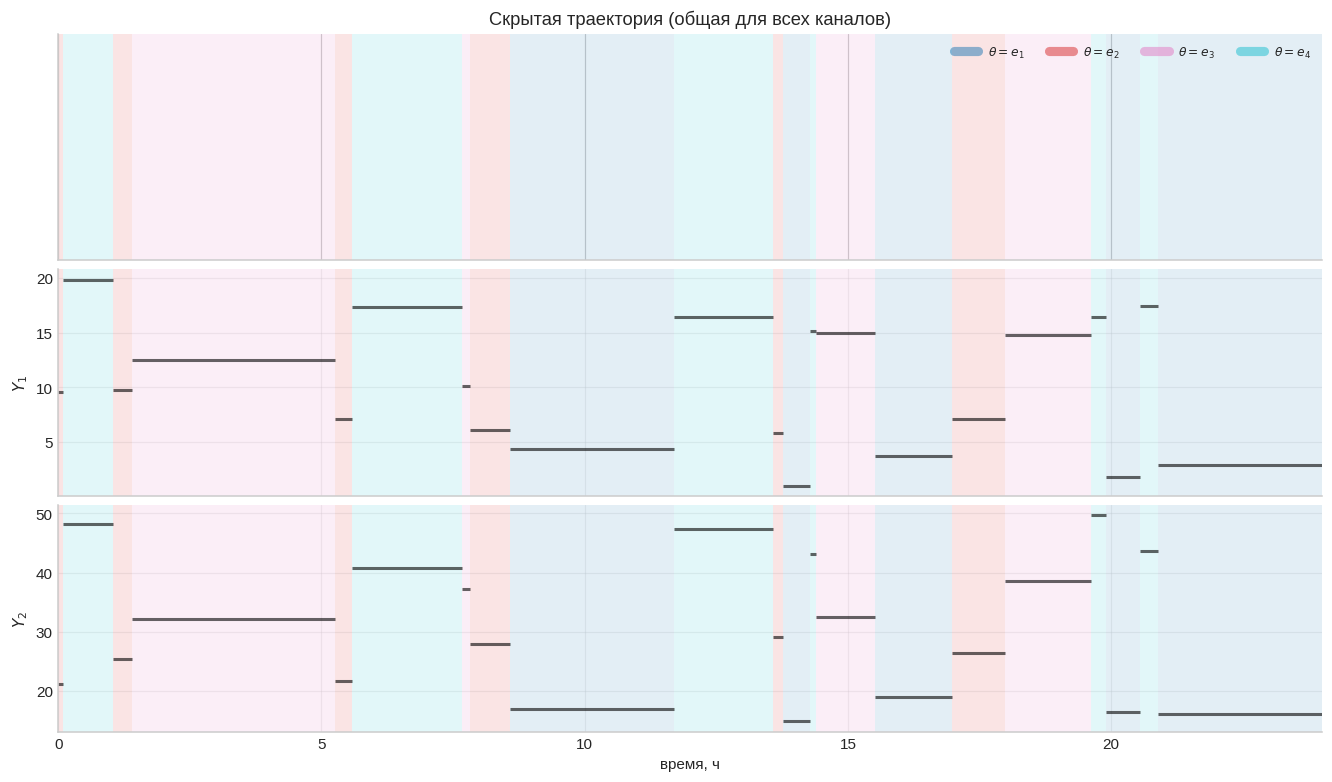

In [3]:
state_colors = plt.cm.tab10(np.linspace(0, 1, N))
starts_h = np.r_[0.0, t[:-1]] / 3600
ends_h = t / 3600


def shade_states(ax):
    for state, left, right in zip(theta, starts_h, ends_h):
        ax.axvspan(left, right, color=state_colors[state], alpha=.12, lw=0)


fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True, layout='constrained')
shade_states(axes[0])
for state in range(N):
    axes[0].plot([], [], color=state_colors[state], lw=6, alpha=.5,
                 label=fr'$\theta=e_{state + 1}$')
axes[0].set_yticks([])
axes[0].set_title('Скрытая траектория (общая для всех каналов)')
axes[0].legend(ncol=N, loc='upper right', fontsize=8)

for comp, ax in zip(range(2), axes[1:]):
    shade_states(ax)
    for value, left, right in zip(y[:, comp], starts_h, ends_h):
        ax.hlines(value, left, right, color='black', lw=2, alpha=.6)
    ax.set_ylabel(fr'$Y_{comp + 1}$')
    ax.grid(alpha=.3)

axes[-1].set_xlabel('время, ч')
axes[-1].set_xlim(0, t[-1] / 3600)
plt.show()

## 3. Потоки наблюдений и стандартизованные остатки

Для одного наблюдения на шаге $h_t=1$:

$$Z = \frac{X - (Y_1+Y_2)}{Y_2/\sqrt{12}},$$

для среднего блока из `ratio` наблюдений:

$$\bar Z = \frac{\bar X - (Y_1+Y_2)}{Y_2/\sqrt{12\,\mathrm{ratio}}}.$$

Обе величины сравниваются с $N(0,1)$; ниже также выборочные асимметрия и
эксцесс. Для канала `uniform` `ratio=1`, поэтому блок из одного наблюдения
совпадает с самим наблюдением -- гистограммы "один шаг" и "блок" для него
идентичны. Это не ошибка, а следствие `ratio=1`.

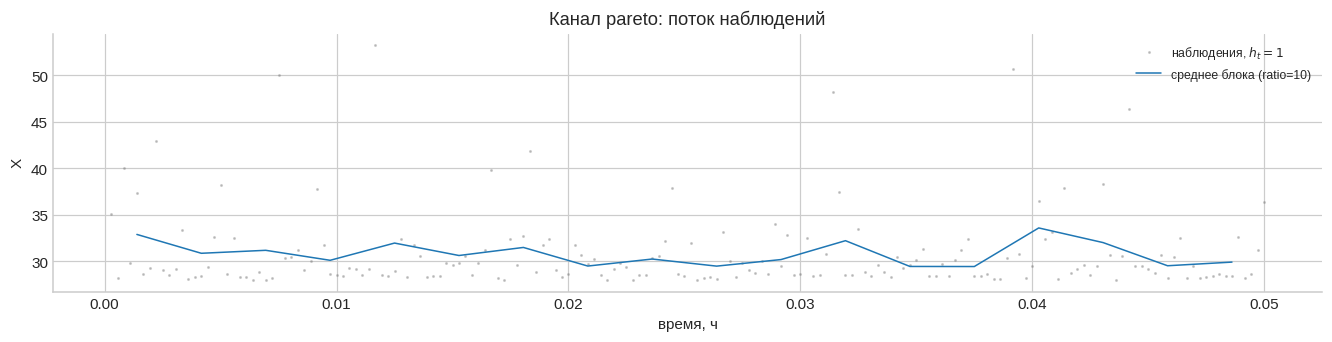

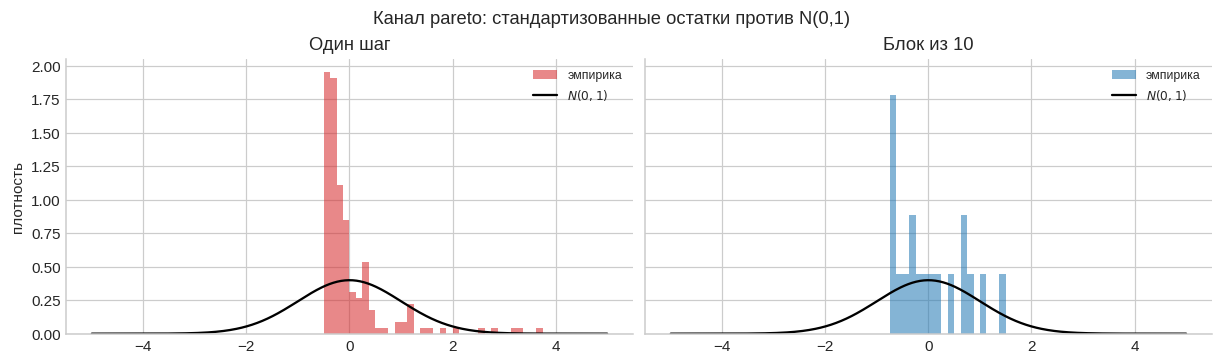

  pareto       шаг  : mean=+0.015  std=0.700  асимметрия=+2.98  эксцесс=+9.88
  pareto       блок : mean=+0.047  std=0.651  асимметрия=+0.65  эксцесс=-0.69


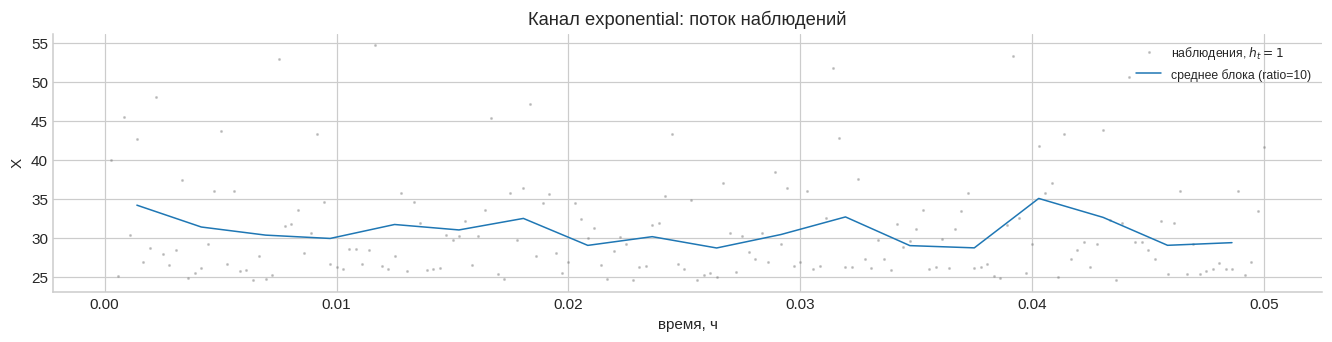

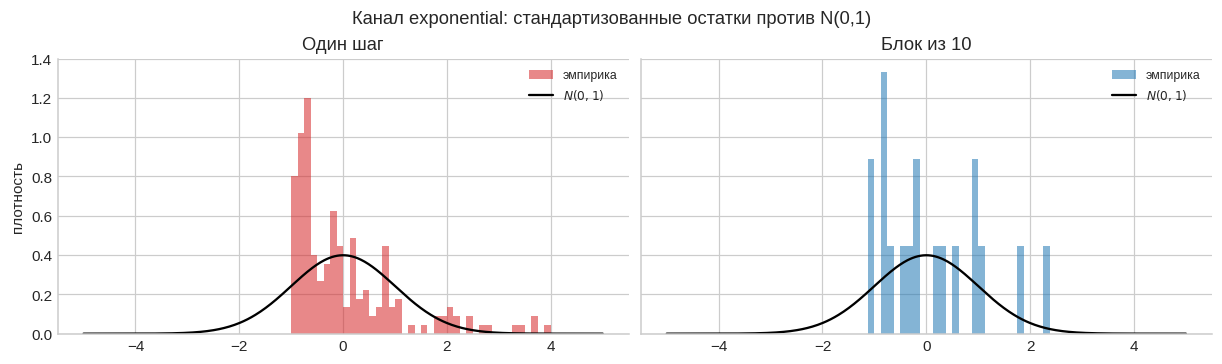

  exponential  шаг  : mean=+0.031  std=1.051  асимметрия=+1.63  эксцесс=+2.44
  exponential  блок : mean=+0.098  std=0.961  асимметрия=+0.69  эксцесс=-0.50


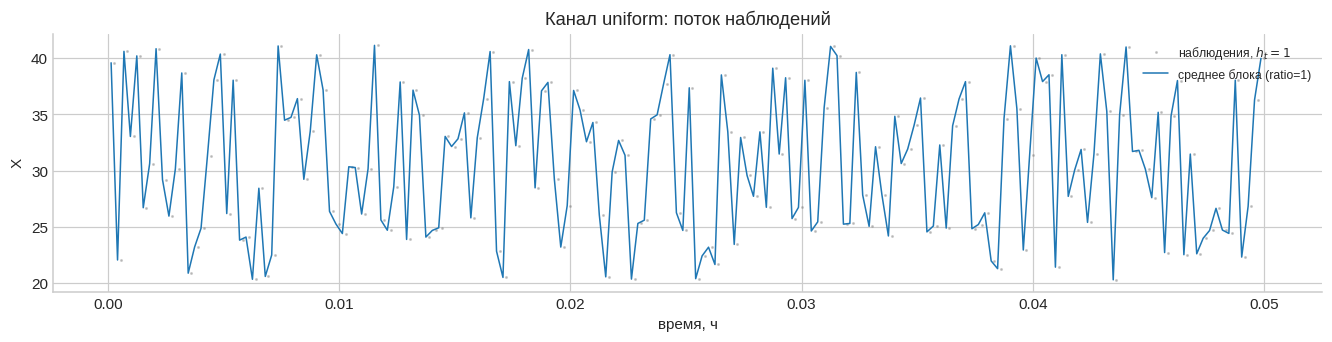

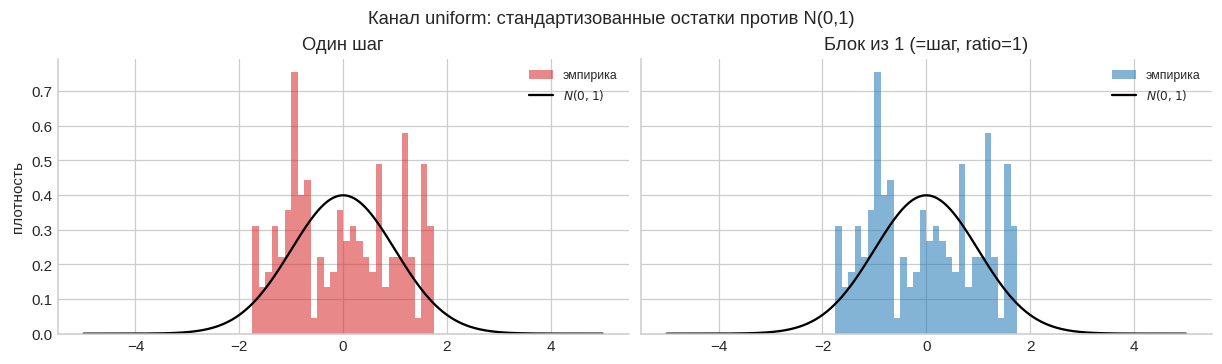

  uniform      шаг  : mean=-0.004  std=1.023  асимметрия=+0.08  эксцесс=-1.28
  uniform      блок : mean=-0.004  std=1.023  асимметрия=+0.08  эксцесс=-1.28


In [4]:
for c in channels:
    d = channel_data[c]
    ratio = d['ratio']
    obs, obs_mean = d['obs'], d['obs_mean']
    t_exact, t_clt = d['t_net_exact'], d['t_net_clt']

    fig, ax = plt.subplots(figsize=(12, 3), layout='constrained')
    ax.plot(t_exact[1:] / 3600, obs, '.', ms=2, alpha=.35, color='tab:gray',
            label='наблюдения, $h_t=1$')
    t_block_centers = (t_clt[:-1] + t_clt[1:]) / 2
    ax.plot(t_block_centers / 3600, obs_mean, color='tab:blue', lw=1,
            label=f'среднее блока (ratio={ratio})')
    ax.set(title=f'Канал {c}: поток наблюдений', xlabel='время, ч', ylabel='X')
    ax.legend(loc='upper right', fontsize=8)
    plt.show()

    # остатки: правдивые Y1, Y2 в момент каждого наблюдения (не оценки фильтра)
    _, y_step = path_at(t_exact[1:])
    mu_step = y_step[:, 0] + y_step[:, 1]
    var_step = y_step[:, 1] ** 2 / 12.0
    z_step = (obs - mu_step) / np.sqrt(var_step)

    mu_block = mu_step.reshape(-1, ratio).mean(axis=1)
    var_block = var_step.reshape(-1, ratio).mean(axis=1) / ratio
    z_block = (obs_mean - mu_block) / np.sqrt(var_block)

    x_grid = np.linspace(-5, 5, 400)
    normal_pdf = np.exp(-x_grid ** 2 / 2) / np.sqrt(2 * np.pi)
    bins = np.linspace(-5, 5, 81)
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True, layout='constrained')
    axs[0].hist(z_step, bins=bins, density=True, alpha=.55, color='tab:red', label='эмпирика')
    axs[1].hist(z_block, bins=bins, density=True, alpha=.55, color='tab:blue', label='эмпирика')
    for a in axs:
        a.plot(x_grid, normal_pdf, color='black', lw=1.5, label='$N(0,1)$')
        a.legend(fontsize=8)
    axs[0].set_title('Один шаг')
    axs[1].set_title(f'Блок из {ratio}' + (' (=шаг, ratio=1)' if ratio == 1 else ''))
    axs[0].set_ylabel('плотность')
    fig.suptitle(f'Канал {c}: стандартизованные остатки против N(0,1)')
    plt.show()

    for label, values in [('шаг', z_step), ('блок', z_block)]:
        centered = (values - values.mean()) / values.std()
        skew = np.mean(centered ** 3)
        kurt = np.mean(centered ** 4) - 3
        print(f'  {c:12s} {label:5s}: mean={values.mean():+.3f}  std={values.std():.3f}  '
              f'асимметрия={skew:+.2f}  эксцесс={kurt:+.2f}')

## 4. Оценки $P(\theta=e_n)$

Точный фильтр -- на своей сетке $h_t=1$, ЦПТ-фильтр -- на своей сетке
$h_t=\mathrm{ratio}$; фон -- истинное состояние. По строке -- компонента
$\theta$, по столбцу -- канал.

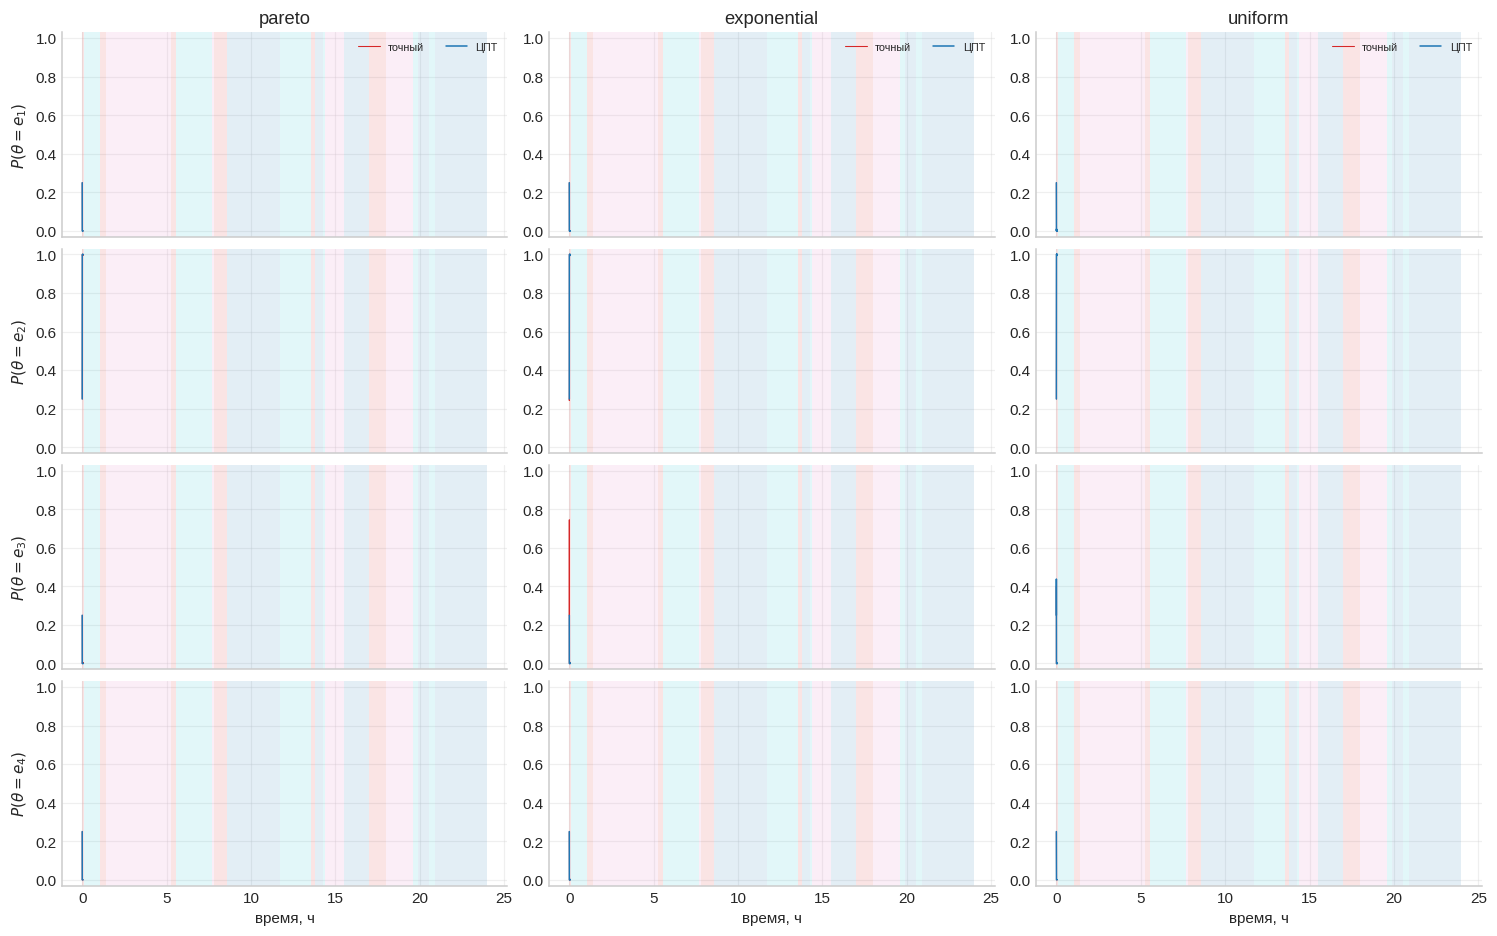

In [5]:
n_cols = len(channels)
fig, axes = plt.subplots(N, n_cols, figsize=(4.5 * n_cols, 2.1 * N),
                          sharex='col', squeeze=False, layout='constrained')
for col, c in enumerate(channels):
    d = channel_data[c]
    for row in range(N):
        ax = axes[row, col]
        shade_states(ax)
        ax.plot(d['t_net_exact_est'] / 3600, d['th_exact'][:, row],
                color='tab:red', lw=.7, label='точный')
        ax.plot(d['t_net_clt_est'] / 3600, d['th_clt'][:, row],
                color='tab:blue', lw=1.0, label='ЦПТ')
        ax.set_ylim(-.03, 1.03)
        ax.grid(alpha=.3)
        if col == 0:
            ax.set_ylabel(fr'$P(\theta=e_{row + 1})$')
        if row == 0:
            ax.set_title(c)
            ax.legend(fontsize=7, ncol=2, loc='upper right')
        if row == N - 1:
            ax.set_xlabel('время, ч')
plt.show()

## 5. Оценки $Y_1$, $Y_2$

По строке -- координата ($Y_1$, $Y_2$), по столбцу -- канал; истина --
чёрная ступенчатая линия.

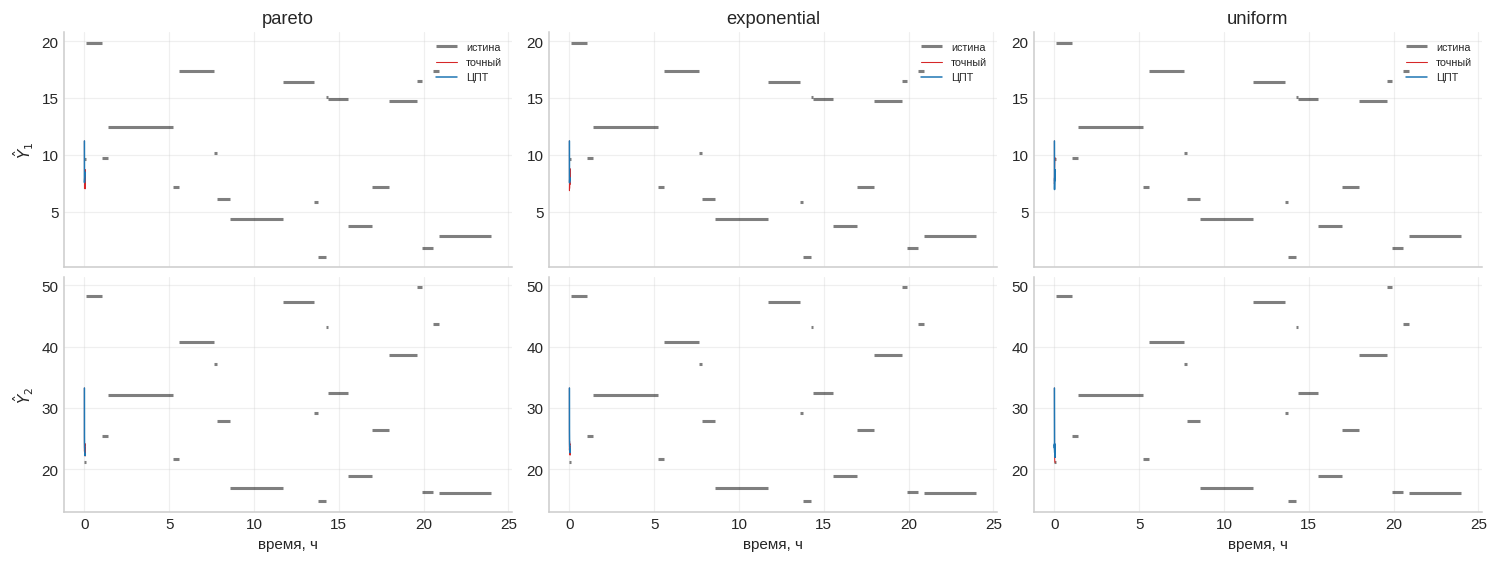

In [6]:
fig, axes = plt.subplots(2, n_cols, figsize=(4.5 * n_cols, 5),
                          sharex='col', squeeze=False, layout='constrained')
for col, c in enumerate(channels):
    d = channel_data[c]
    for comp in range(2):
        ax = axes[comp, col]
        for value, left, right in zip(y[:, comp], starts_h, ends_h):
            ax.hlines(value, left, right, color='black', lw=2, alpha=.5, label='истина')
        ax.plot(d['t_net_exact_est'] / 3600, d['y_exact'][:, comp],
                color='tab:red', lw=.7, label='точный')
        ax.plot(d['t_net_clt_est'] / 3600, d['y_clt'][:, comp],
                color='tab:blue', lw=1.0, label='ЦПТ')
        ax.grid(alpha=.3)
        if col == 0:
            ax.set_ylabel(fr'$\hat Y_{comp + 1}$')
        if comp == 0:
            ax.set_title(c)
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), fontsize=7)
        if comp == 1:
            ax.set_xlabel('время, ч')
plt.show()

## 6. RMSE на общей ЦПТ-сетке

Истина берётся на сетке ЦПТ-фильтра `path_at`; точный фильтр прорежен
`[::ratio]` для выравнивания. RMSE по $\theta$ -- по всем $N$ компонентам
one-hot вектора.

канал         фильтр                точек   RMSE th   RMSE Y1   RMSE Y2
pareto        точный (прорежен)        19    0.0993    1.9087    3.5081
pareto        ЦПТ                      19    0.0993    1.5759    3.4668
exponential   точный (прорежен)        19    0.0993    1.7233    3.6162
exponential   ЦПТ                      19    0.0994    1.8116    3.8190
uniform       точный (прорежен)       181    0.0411    0.6621    1.5062
uniform       ЦПТ                     181    0.0428    1.6170    2.4119


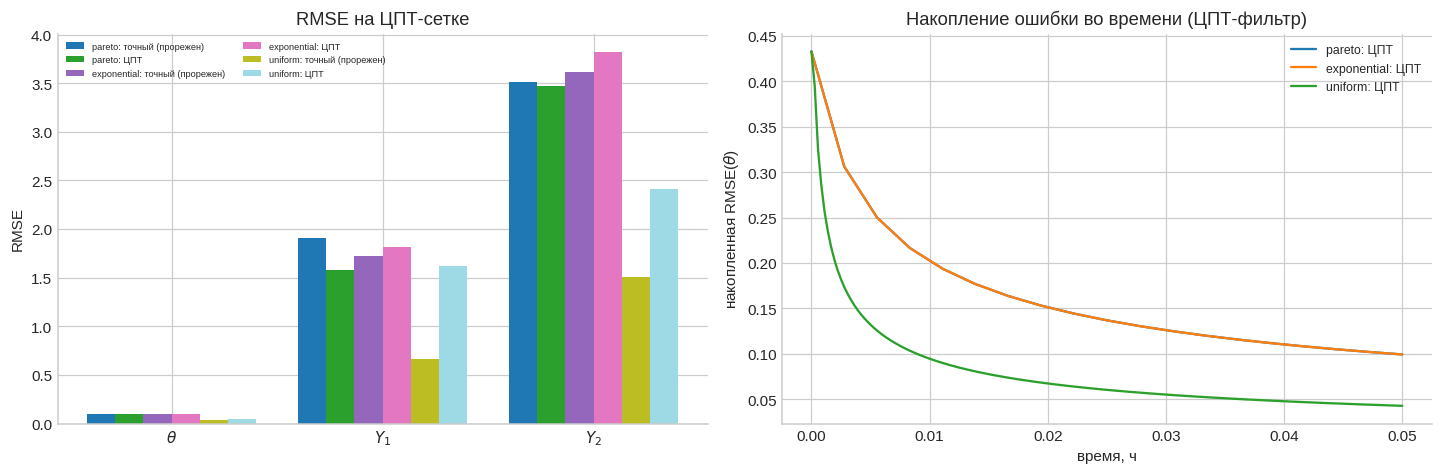

In [7]:
def onehot(states, n):
    return np.eye(n)[states]


def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


rmse_rows = []
for c in channels:
    d = channel_data[c]
    ratio = d['ratio']
    true_state_clt, true_y_clt = path_at(d['t_net_clt_est'])
    true_onehot_clt = onehot(true_state_clt, N)

    n_clt = min(len(true_onehot_clt), d['th_clt'].shape[0])
    rmse_theta_clt = rmse(d['th_clt'][:n_clt], true_onehot_clt[:n_clt])
    rmse_y1_clt = rmse(d['y_clt'][:n_clt, 0], true_y_clt[:n_clt, 0])
    rmse_y2_clt = rmse(d['y_clt'][:n_clt, 1], true_y_clt[:n_clt, 1])

    th_exact_thin = d['th_exact'][::ratio]
    y_exact_thin = d['y_exact'][::ratio]
    n_thin = min(len(true_onehot_clt), th_exact_thin.shape[0])
    rmse_theta_exact = rmse(th_exact_thin[:n_thin], true_onehot_clt[:n_thin])
    rmse_y1_exact = rmse(y_exact_thin[:n_thin, 0], true_y_clt[:n_thin, 0])
    rmse_y2_exact = rmse(y_exact_thin[:n_thin, 1], true_y_clt[:n_thin, 1])

    rmse_rows.append((c, 'точный (прорежен)', n_thin, rmse_theta_exact, rmse_y1_exact, rmse_y2_exact))
    rmse_rows.append((c, 'ЦПТ', n_clt, rmse_theta_clt, rmse_y1_clt, rmse_y2_clt))

print(f'{"канал":<14}{"фильтр":<20}{"точек":>7}{"RMSE th":>10}{"RMSE Y1":>10}{"RMSE Y2":>10}')
for row in rmse_rows:
    c, label, n, rth, ry1, ry2 = row
    print(f'{c:<14}{label:<20}{n:>7}{rth:>10.4f}{ry1:>10.4f}{ry2:>10.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), layout='constrained')
positions = np.arange(3)
width = 0.8 / (2 * n_cols)
colors = plt.cm.tab20(np.linspace(0, 1, max(2 * n_cols, 2)))
for k, (c, label, n, rth, ry1, ry2) in enumerate(rmse_rows):
    axes[0].bar(positions + (k - len(rmse_rows) / 2 + .5) * width, [rth, ry1, ry2],
                width, label=f'{c}: {label}', color=colors[k])
axes[0].set_xticks(positions)
axes[0].set_xticklabels([r'$\theta$', r'$Y_1$', r'$Y_2$'])
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE на ЦПТ-сетке')
axes[0].legend(fontsize=6, ncol=2)

for c in channels:
    d = channel_data[c]
    true_state_clt, _ = path_at(d['t_net_clt_est'])
    true_onehot_clt = onehot(true_state_clt, N)
    n_clt = min(len(true_onehot_clt), d['th_clt'].shape[0])
    sq = np.mean((d['th_clt'][:n_clt] - true_onehot_clt[:n_clt]) ** 2, axis=1)
    cumulative = np.sqrt(np.cumsum(sq) / np.arange(1, len(sq) + 1))
    axes[1].plot(d['t_net_clt_est'][:n_clt] / 3600, cumulative, label=f'{c}: ЦПТ')
axes[1].set(xlabel='время, ч', ylabel=r'накопленная RMSE($\theta$)',
            title='Накопление ошибки во времени (ЦПТ-фильтр)')
axes[1].legend(fontsize=8)
plt.show()

## 7. Расхождение ЦПТ минус точный

Тепловые карты по каналам: ЦПТ-оценка минус точная (прореженная `[::ratio]`),
на общей ЦПТ-сетке. Цвет -- знак и величина расхождения между двумя
фильтрами, а не ошибка против истины.

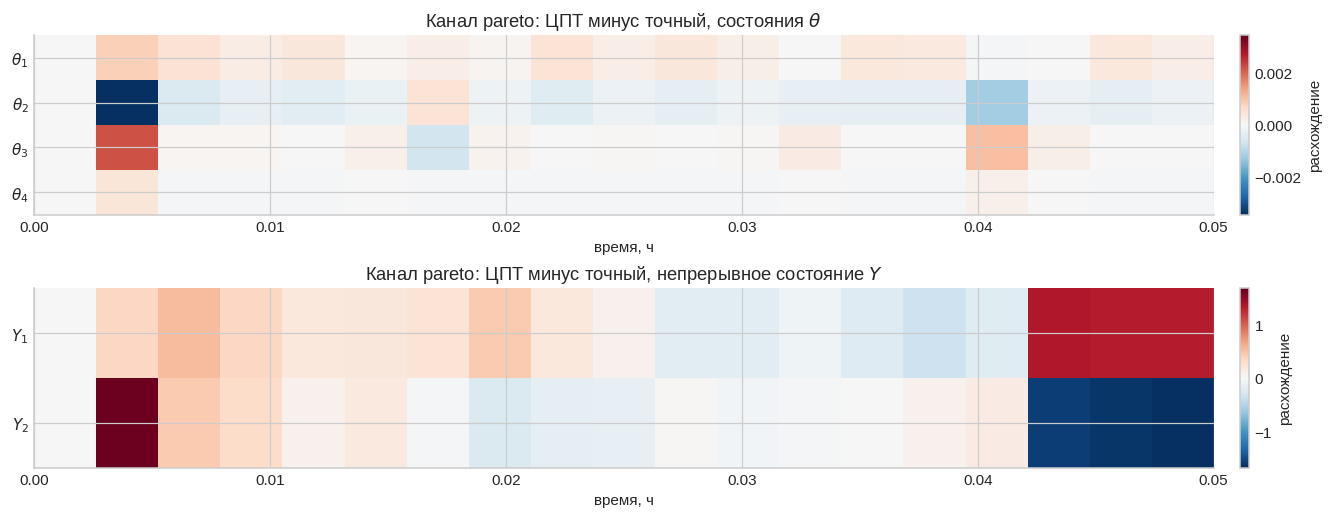

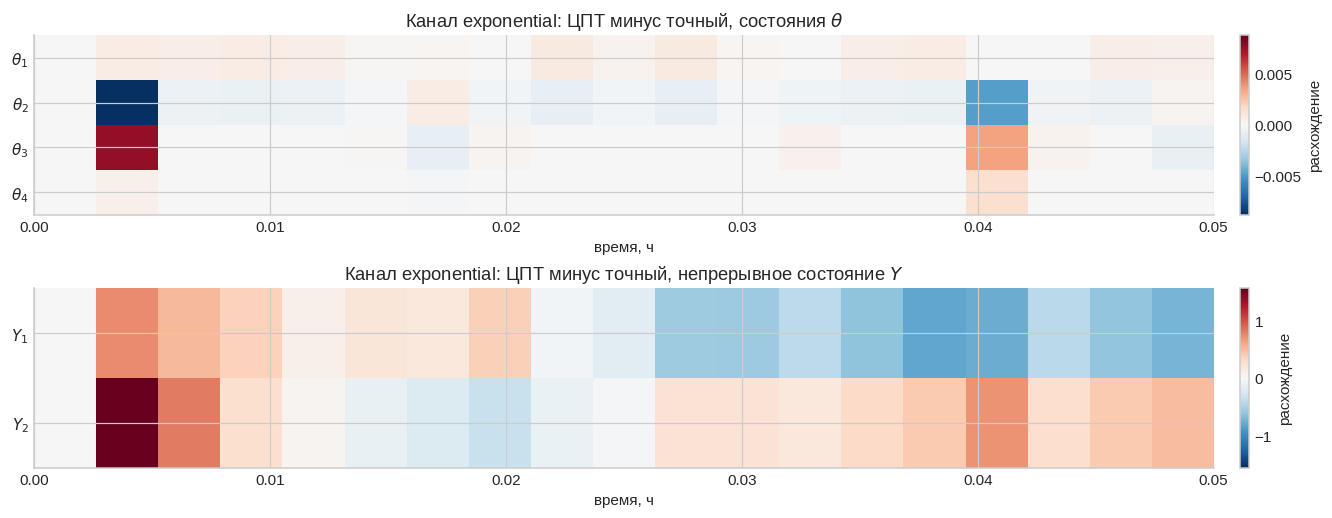

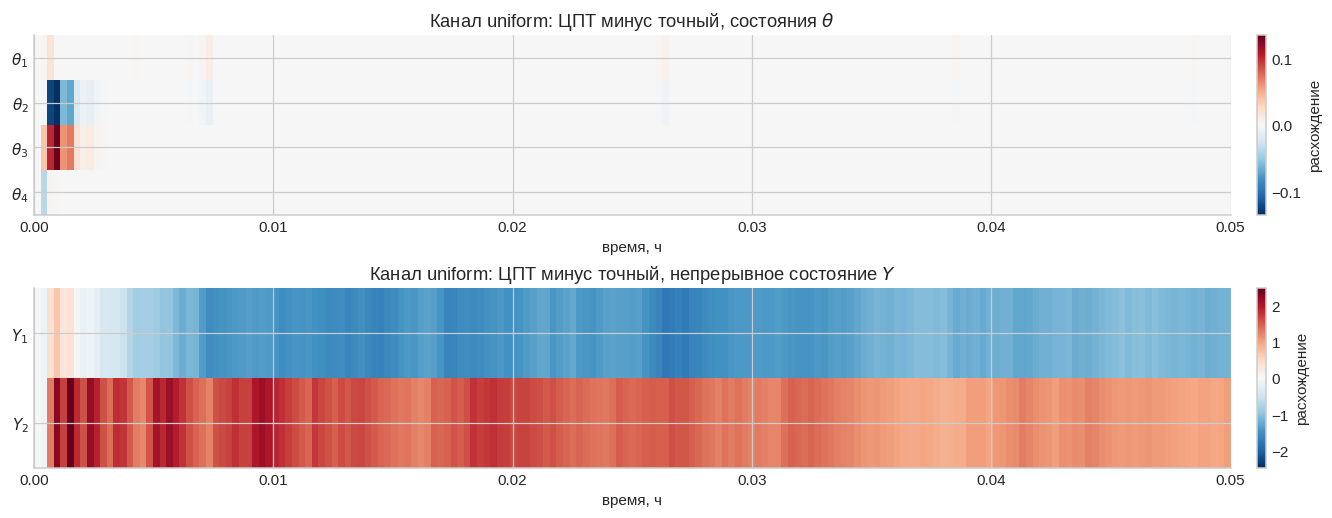

In [8]:
for c in channels:
    d = channel_data[c]
    ratio = d['ratio']
    th_exact_thin = d['th_exact'][::ratio]
    y_exact_thin = d['y_exact'][::ratio]
    n = min(d['th_clt'].shape[0], th_exact_thin.shape[0])
    if n < 2:
        print(f'канал {c}: слишком мало общих точек ({n}) для тепловой карты, пропуск')
        continue
    theta_diff = (d['th_clt'][:n] - th_exact_thin[:n]).T
    y_diff = (d['y_clt'][:n] - y_exact_thin[:n]).T
    tgrid = d['t_net_clt_est'][:n] / 3600

    fig, axs = plt.subplots(2, 1, figsize=(12, 4.6), layout='constrained')
    for ax, diff, labels, title in [
        (axs[0], theta_diff, [fr'$\theta_{i + 1}$' for i in range(N)], 'состояния $\\theta$'),
        (axs[1], y_diff, [r'$Y_1$', r'$Y_2$'], 'непрерывное состояние $Y$'),
    ]:
        limit = max(np.max(np.abs(diff)), 1e-12)
        image = ax.imshow(diff, aspect='auto', cmap='RdBu_r', vmin=-limit, vmax=limit,
                           extent=[tgrid[0], tgrid[-1], len(labels) - .5, -.5])
        ax.set(yticks=np.arange(len(labels)), yticklabels=labels, xlabel='время, ч',
               title=f'Канал {c}: ЦПТ минус точный, {title}')
        fig.colorbar(image, ax=ax, pad=.01, label='расхождение')
    plt.show()

## 8. Выводы

1. Все три канала прогоняются на одной и той же скрытой траектории
   $(\theta_t, Y_t)$ и (для точного потока наблюдений) с общими случайными
   числами -- различия между каналами объясняются только формой шума
   $\varepsilon$, а не разными реализациями сигнала.
2. Усреднение блока из `ratio` наблюдений заметно приближает
   стандартизованные остатки к $N(0,1)$ (снижает асимметрию и эксцесс) для
   тяжелохвостых каналов (`pareto`, `exponential`); для `uniform` `ratio=1`,
   и гистограммы "шаг"/"блок" совпадают тождественно -- это не ошибка, а
   прямое следствие того, что блок из одного наблюдения есть само
   наблюдение.
3. На общей ЦПТ-сетке ЦПТ-фильтр использует в `ratio` раз меньше моментов
   обновления, чем точный; величина и знак расхождения RMSE между ними
   зависят от канала и видны как из столбчатой диаграммы RMSE, так и из
   тепловых карт §7 -- по последним можно локализовать во времени, где
   гауссовская аппроксимация отклоняется от точного правдоподобия сильнее
   всего.
4. Эти выводы основаны на конкретном (возможно, укороченном для дымового
   прогона) сохранённом прогоне `saved_path_<EXP_ID>/comparison.npz`;
   количественные величины RMSE не следует переносить на другие горизонты
   или семена без пересчёта.